In [51]:
from google.colab import drive
drive.mount('/content/drive')
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
IMG_DIR = "/content/drive/MyDrive/Solar panel Detection/Solar_panel_Image"  # The dataset directory
MODEL_PATH = '/content/drive/MyDrive/Solar panel Detection/Solar_panel_Image1.pth'  # Path for model saving

In [53]:
# buka dataset dari google drive
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow
train_ds = image_dataset_from_directory(
    IMG_DIR,
    image_size=(224, 224),
    interpolation="bilinear",
    crop_to_aspect_ratio=True,
    validation_split=0.2,
    subset="training",  # Add this line to specify the subset as "training"
    seed=42,
    batch_size=32,
    shuffle=True
)

# If you also need a validation dataset, create another dataset with subset="validation"
val_ds = image_dataset_from_directory(
    IMG_DIR,
    image_size=(224, 224),
    interpolation="bilinear",
    crop_to_aspect_ratio=True,
    validation_split=0.2,
    subset="validation",  # Specify subset as "validation" for the validation dataset
    seed=42,
    batch_size=32,
    shuffle=True  # Usually no need to shuffle validation data
)
print(train_ds)
print(val_ds)


Found 905 files belonging to 6 classes.
Using 724 files for training.
Found 905 files belonging to 6 classes.
Using 181 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [54]:
class_name=train_ds.class_names
print("Class names:", class_name)

Class names: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


### Balancing Training Dataset

In [55]:
from collections import Counter

DS_AU_Training = 170

# ======================================================
# AUGMENTATION LAYER
# ======================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

# ======================================================
# AMBIL DATA TRAIN
# ======================================================

images = []
labels = []
for batch_images, batch_labels in train_ds:
    for i in range(len(batch_labels)):
        images.append(batch_images[i])
        labels.append(batch_labels[i].numpy())
images = tf.stack(images)
labels = np.array(labels)
# ======================================================
# CEK DISTRIBUSI AWAL
# ======================================================

print("\nOriginal Distribution:\n")
counter = Counter(labels)
for class_id, count in counter.items():
    print(f"{class_name[class_id]} : {count}") # Changed to use global 'class_name'
# ======================================================
# BALANCING DATASET
# ======================================================
balanced_images = []
balanced_labels = []
for class_id, current_class_name in enumerate(class_name): # Changed to use global 'class_name' and renamed loop variable
    # ambil image per class
    idx = np.where(labels == class_id)[0]
    class_images = tf.gather(images, idx)
    original_count = len(class_images)

    # ==================================================
    # MASUKKAN IMAGE ASLI
    # ==================================================
    for img in class_images:
        balanced_images.append(img)
        balanced_labels.append(class_id)
    # ==================================================
    # AUGMENTASI JIKA KURANG DARI TARGET
    # ==================================================
    if original_count < DS_AU_Training:
        needed = DS_AU_Training - original_count
        # print(f"Augmented : {needed}") # Removed for cleaner output
        for i in range(needed):
            rand_idx = np.random.randint(0, original_count)
            img = class_images[rand_idx]
            aug_img = data_augmentation(
                tf.expand_dims(img, axis=0),
                training=True
            )

            balanced_images.append(aug_img[0])
            balanced_labels.append(class_id)

# ======================================================
# CONVERT TO TF.DATA
# ======================================================

balanced_images = tf.stack(balanced_images)
balanced_labels = np.array(balanced_labels)

balanced_train_ds = tf.data.Dataset.from_tensor_slices(
    (balanced_images, balanced_labels)
)
balanced_train_ds = balanced_train_ds.shuffle(
    len(balanced_labels),
    seed=42
)
balanced_train_ds = balanced_train_ds.batch(32)
balanced_train_ds = balanced_train_ds.prefetch(
    tf.data.AUTOTUNE
)

# ======================================================
# CEK DISTRIBUSI AKHIR
# ======================================================

print("\nBalanced Distribution:\n")
final_counter = Counter(balanced_labels)
for class_id, count in final_counter.items():
    print(f"{class_name[class_id]} : {count}") # Changed to use global 'class_name'


Original Distribution:

Electrical-damage : 82
Snow-Covered : 104
Clean : 163
Dusty : 172
Physical-Damage : 45
Bird-drop : 158

Balanced Distribution:

Bird-drop : 170
Clean : 170
Dusty : 172
Electrical-damage : 170
Physical-Damage : 170
Snow-Covered : 170


### Balancing Validation Dataset

In [56]:
DS_AU_Val = 50

val_images = []
val_labels = []
for batch_images, batch_labels in val_ds:
    for i in range(len(batch_labels)):
        val_images.append(batch_images[i])
        val_labels.append(batch_labels[i].numpy())
val_images = tf.stack(val_images)
val_labels = np.array(val_labels)

# ======================================================
# CEK DISTRIBUSI AWAL VALIDASI
# ======================================================

print("\nOriginal Validation Distribution:\n")
counter_val = Counter(val_labels)
for class_id, count in counter_val.items():
    print(f"{class_name[class_id]} : {count}")

# ======================================================
# BALANCING DATASET VALIDASI (DUPLIKASI SAJA, TANPA AUGMENTASI)
# ======================================================
balanced_val_images = []
balanced_val_labels = []

for class_id, current_class_name in enumerate(class_name):
    # Ambil image per class
    idx = np.where(val_labels == class_id)[0]
    class_val_images = tf.gather(val_images, idx)
    original_count = len(class_val_images)

    # MASUKKAN IMAGE ASLI
    for img in class_val_images:
        balanced_val_images.append(img)
        balanced_val_labels.append(class_id)

    # DUPLIKASI JIKA KURANG DARI TARGET (TANPA AUGMENTASI)
    if original_count < DS_AU_Val:
        needed = DS_AU_Val - original_count
        # Randomly select and duplicate existing images until TARGET_COUNT is reached
        for i in range(needed):
            if original_count > 0: # Ensure there are images to duplicate
                rand_idx = np.random.randint(0, original_count)
                img = class_val_images[rand_idx]
                balanced_val_images.append(img)
                balanced_val_labels.append(class_id)

# ======================================================
# CONVERT TO TF.DATA VALIDASI
# ======================================================

balanced_val_images = tf.stack(balanced_val_images)
balanced_val_labels = np.array(balanced_val_labels)

balanced_val_ds = tf.data.Dataset.from_tensor_slices(
    (balanced_val_images, balanced_val_labels)
)
balanced_val_ds = balanced_val_ds.shuffle(
    len(balanced_val_labels),
    seed=42
)
balanced_val_ds = balanced_val_ds.batch(32)
balanced_val_ds = balanced_val_ds.prefetch(
    tf.data.AUTOTUNE
)

# ======================================================
# CEK DISTRIBUSI AKHIR VALIDASI
# ======================================================

print("\nBalanced Validation Distribution:\n")
final_counter_val = Counter(balanced_val_labels)
for class_id, count in final_counter_val.items():
    print(f"{class_name[class_id]} : {count}")



Original Validation Distribution:

Bird-drop : 41
Snow-Covered : 18
Clean : 38
Dusty : 47
Physical-Damage : 21
Electrical-damage : 16

Balanced Validation Distribution:

Bird-drop : 50
Clean : 50
Dusty : 50
Electrical-damage : 50
Physical-Damage : 50
Snow-Covered : 50


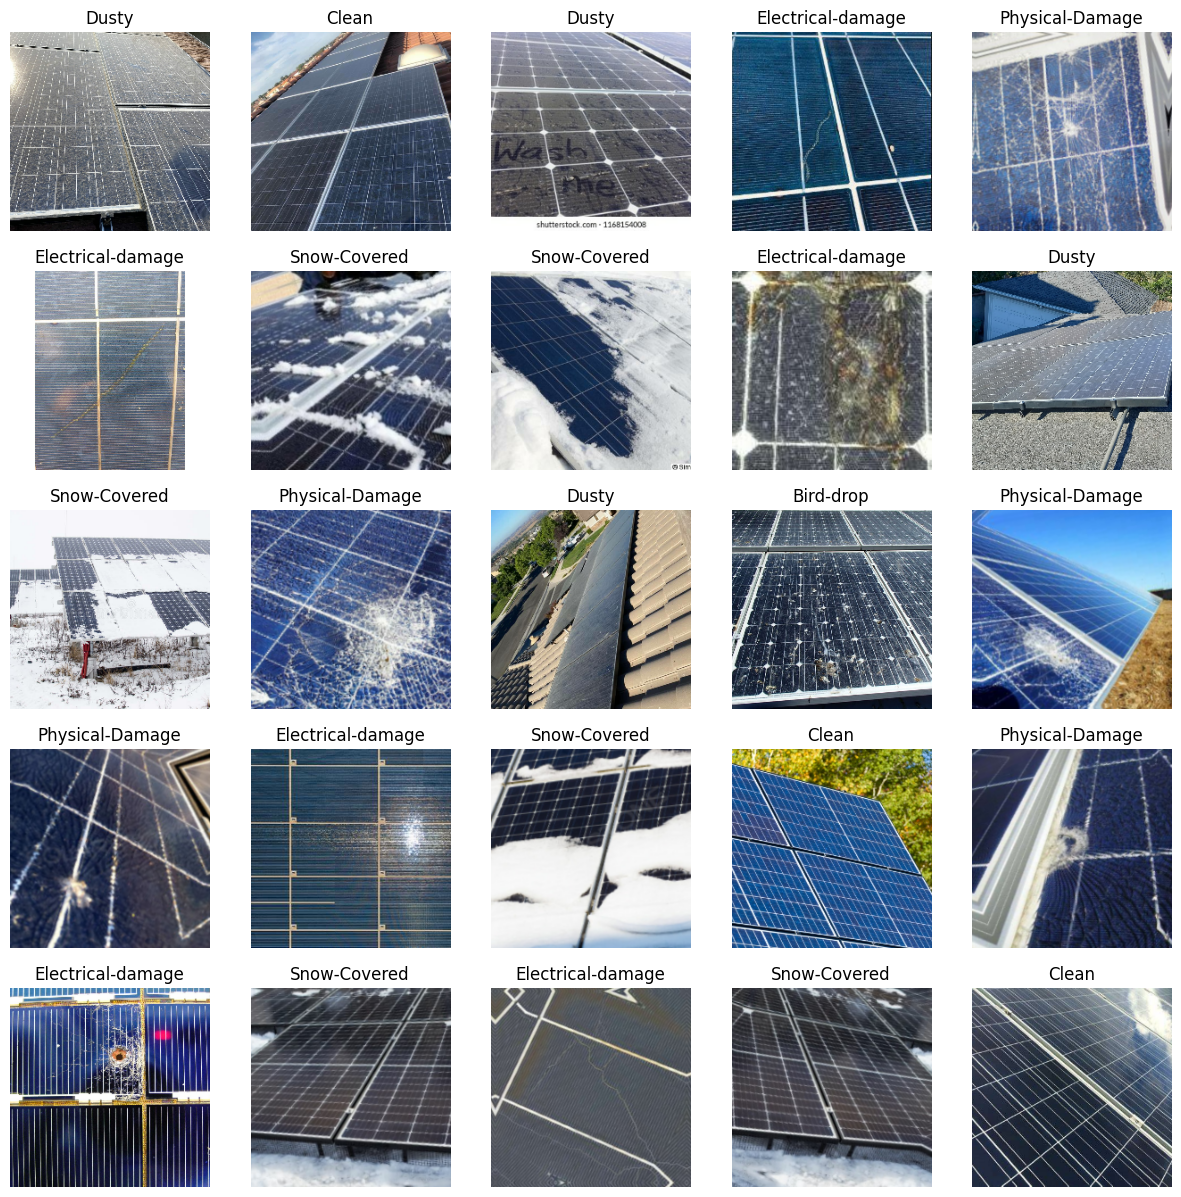

In [57]:
plt.figure(figsize=(15,15))

for images,labels in balanced_train_ds.take(1):
    for i in range(25):
        ax=plt.subplot(5,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_name[labels[i]])
        plt.axis('off')

### Create Model

In [107]:
base_model=tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

# base_model.trainable=False

# ======================================================
# FINE-TUNING
# ======================================================
base_model.trainable = True
# freeze layer awal
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [108]:
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D, BatchNormalization, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

inputs = tf.keras.Input(shape=(224,224,3))  # INPUT
x = preprocess_input(inputs)                # PREPROCESSING
x = base_model(x, training= False)            # FEATURE EXTRACTION (training=True untuk fine-tuning)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x) # dropout diperbesar untuk mengurangi overfitting
x = Dense(len(class_name), activation='softmax')(x)
model = Model(inputs=inputs, outputs=x) # Corrected: Use the custom 'inputs' tensor
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 1,534,086 (5.85 MB)

 Non-trainable params: 731,584 (2.79 MB)

### Check Model Layer

In [60]:
for layer in base_model.layers:
    if "block" in layer.name and "project_bn" in layer.name:
        print(layer.name, layer.output.shape)

In [61]:
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 1,206,080 (4.60 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

### Trainign model

In [109]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
             loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [129]:
epoch=30

history=model.fit(
          balanced_train_ds,
          validation_data=val_ds, # Changed to use balanced validation dataset
          epochs=epoch,
          batch_size = 32,
        #   callbacks=[
        #      tf.keras.callbacks.EarlyStopping(
        #          monitor="val_loss",
        #          min_delta=1e-2,
        #          patience=7, # Increased patience slightly
        #          verbose=1,
        #          restore_best_weights=True
        #      )
        #  ]
          )

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.9941 - loss: 0.0177 - val_accuracy: 0.7127 - val_loss: 3.4493
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9922 - loss: 0.0203 - val_accuracy: 0.7072 - val_loss: 4.0196
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9961 - loss: 0.0095 - val_accuracy: 0.7238 - val_loss: 3.4094
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9902 - loss: 0.0238 - val_accuracy: 0.7845 - val_loss: 2.9567
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9932 - loss: 0.0319 - val_accuracy: 0.6685 - val_loss: 5.5873
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.9971 - loss: 0.0125 - val_accuracy: 0.6630 - val_loss: 6.0769
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9961 - loss: 0.0133 - val_accuracy: 0.6961 - val_loss: 4.8369
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.9912 - loss: 0.0485 - val_accuracy: 0.

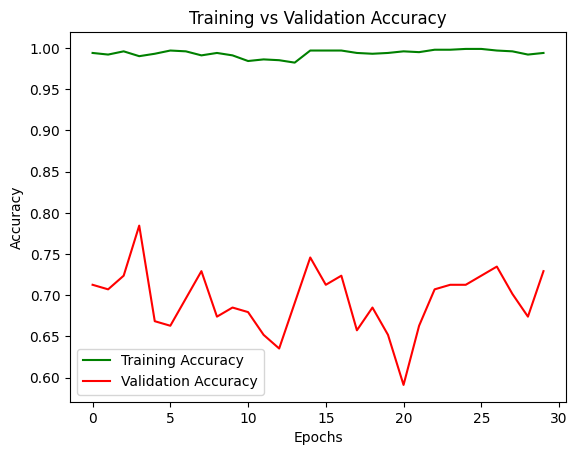

In [130]:
get_ac = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(len(get_ac))

plt.plot(epochs_range, get_ac, 'g', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [131]:
loss_train,accuracy_train=model.evaluate(train_ds)
loss,accuracy=model.evaluate(val_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 369ms/step - accuracy: 0.9530 - loss: 0.2198
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 534ms/step - accuracy: 0.7293 - loss: 4.9330


### Confusion Matrix

   Model  Accuracy (%)  Precision  Recall  F1-score
0  Model         72.93     0.7818  0.7293    0.7293


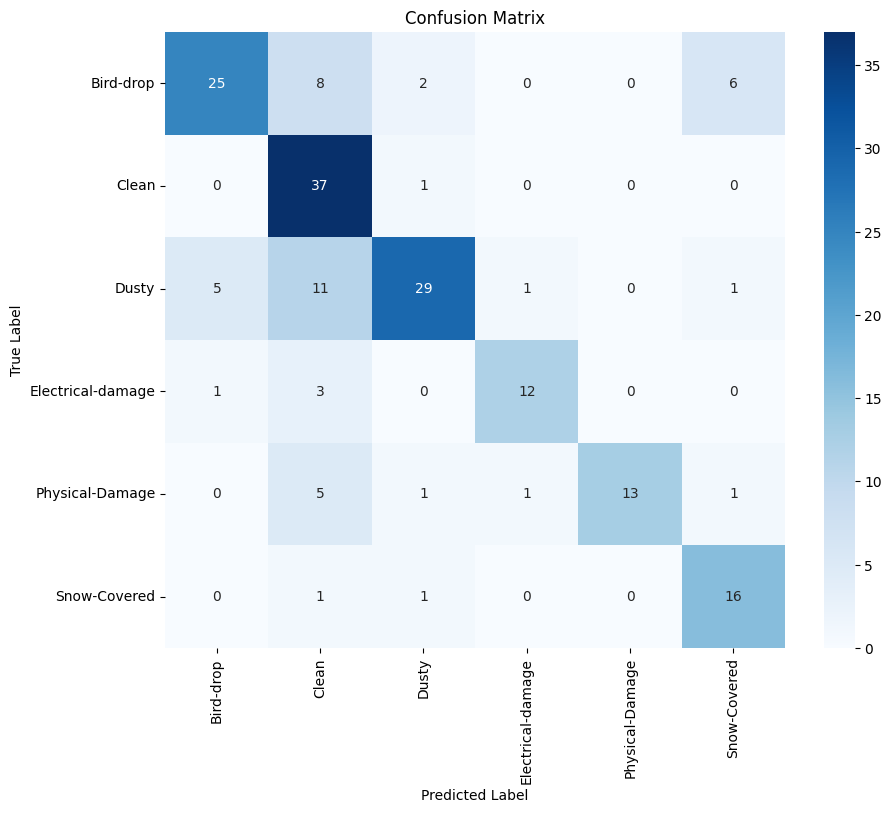

In [132]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
# =========================
# Prediction
# =========================
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# =========================
# Evaluation Metrics
# =========================
accuracy  = accuracy_score(y_true, y_pred) * 100
precision = precision_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)
recall = recall_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)
f1 = f1_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

# =========================
# Result Table
# =========================
result_df = pd.DataFrame({
    "Model": ["Model"],
    "Accuracy (%)": [round(accuracy, 2)],
    "Precision": [round(precision, 4)],
    "Recall": [round(recall, 4)],
    "F1-score": [round(f1, 4)]
})

print(result_df)

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### GradCam

In [140]:
last_conv_layer_name = "Conv_1"

In [141]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, pred_index=None):
    # Get the last convolutional layer from the MobileNetV2 base model
    # 'last_conv_layer_name' is defined in cell LUEVKZZk2lHX as "Conv_1"
    # The base_model itself is a layer named 'mobilenetv2_1.00_224' within the overall 'model'
    last_conv_layer = model.get_layer('mobilenetv2_1.00_224').get_layer(last_conv_layer_name)

    # Create a new model that takes the original model's input
    # and outputs the activations of the last convolutional layer and the final predictions.
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, # Use the overall model's input(s)
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        # Ensure img_array is a TensorFlow tensor and pass it to grad_model.
        # model.inputs is a list of Tensors, so grad_model expects a list of inputs.
        last_conv_layer_output_activations, predictions = grad_model(tf.convert_to_tensor(img_array))

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute the gradients of the predicted class with respect to the
    # activations of the last convolutional layer.
    grads = tape.gradient(class_channel, last_conv_layer_output_activations)

    # Calculate weighted average of gradients (pooled_grads)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is"
    # with regard to the desired class.
    heatmap = last_conv_layer_output_activations[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to a range of 0-1
    heatmap = tf.maximum(heatmap, 0) # Apply ReLU
    max_val = tf.reduce_max(heatmap)
    if tf.abs(max_val) < 1e-5: # Handle case where heatmap is all zeros (to avoid division by zero)
        heatmap = tf.zeros_like(heatmap)
    else:
        heatmap = heatmap / max_val

    return heatmap.numpy()

In [142]:
for images, labels in val_ds.take(1):
    img = images[0]          # ambil 1 gambar
    label = labels[0]        # labelnya

In [143]:
import numpy as np
# Removed: from tensorflow.keras.applications.mobilenet import preprocess_input (if it was there)

img_array = np.expand_dims(img.numpy(), axis=0)
# The 'preprocess_input' call for img_array is removed here
# as the model's graph already handles it. img_array should be raw (0-255).


In [144]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, pred_index=None):
    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(img_array)

        # Get the mobilenetv2_1.00_224 base model layer
        base_model_layer = model.get_layer('mobilenetv2_1.00_224')

        # Pass the input through the base_model to get feature maps
        conv_outputs = base_model_layer(input_tensor, training=False)
        tape.watch(conv_outputs) # Watch the feature maps for gradient computation

        # Dynamically find the classification head layers after mobilenetv2_1.00_224
        gap_layer = None
        dropout_layer = None
        final_dense_layer = None

        found_efficientnet = False
        for layer in model.layers:
            if layer.name == 'mobilenetv2_1.00_224':
                found_efficientnet = True
                continue # Skip the mobilenetv2_1.00_224 layer itself

            if found_efficientnet:
                if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D) and gap_layer is None:
                    gap_layer = layer
                elif isinstance(layer, tf.keras.layers.Dropout) and dropout_layer is None:
                    dropout_layer = layer
                elif isinstance(layer, tf.keras.layers.Dense) and final_dense_layer is None:
                    final_dense_layer = layer

        if not gap_layer or not dropout_layer or not final_dense_layer:
            raise ValueError("Could not find all required classification head layers for Grad-CAM in the model.")

        # Pass conv_outputs through the dynamically found classification head layers
        x = gap_layer(conv_outputs)
        x = dropout_layer(x, training=False) # Ensure dropout is in inference mode
        preds = final_dense_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradients of the class score with respect to the feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # rata-rata gradien
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # weighting
    conv_outputs = conv_outputs[0] # Get the feature maps for the first image in the batch
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # normalisasi
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    if tf.math.is_nan(tf.reduce_max(heatmap)): # Handle case where heatmap is all zeros
        heatmap = tf.zeros_like(heatmap)

    return heatmap.numpy()


heatmap = make_gradcam_heatmap(
    img_array,
    model
)

Using test image: /content/drive/MyDrive/Solar panel Detection/Testing_solar_Panel/images_2.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted label for the test image: Electrical-damage


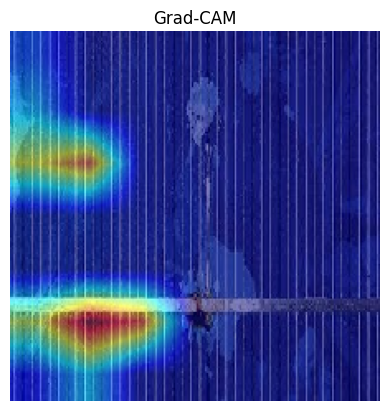

In [145]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_gradcam(img_tensor, heatmap, alpha=0.4):
    # Convert tensor image to numpy array and ensure uint8 type
    img_np = img_tensor.numpy().astype("uint8")

    # Resize heatmap to the original image size
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized) # Scale to 0-255

    # Apply a colormap to the heatmap
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Convert heatmap_colored from BGR (OpenCV default) to RGB for matplotlib
    heatmap_colored_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay the heatmap on the original image
    superimposed_img = cv2.addWeighted(img_np, 1 - alpha, heatmap_colored_rgb, alpha, 0)

    # Display the image
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title("Grad-CAM")
    plt.show()

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet import preprocess_input # Ensure preprocess_input is available here

# Define the path to the new test image directory
TEST_IMAGE_DIR = "/content/drive/MyDrive/Solar panel Detection/Testing_solar_Panel"

# List all files in the test directory (assuming there's at least one image)
# You might want to specify a particular image if there are many
test_image_files = os.listdir(TEST_IMAGE_DIR)
if not test_image_files:
    raise ValueError(f"No images found in the directory: {TEST_IMAGE_DIR}")

# Take the first image found for demonstration
test_image_path = os.path.join(TEST_IMAGE_DIR, test_image_files[0])
print(f"Using test image: {test_image_path}")

# Load the image and resize it to the target size (224, 224)
img_test = image.load_img(test_image_path, target_size=(224, 224))
img_test_array = image.img_to_array(img_test)

# Expand dimensions to create a batch of 1 image. This is the raw image input.
img_test_array_expanded = np.expand_dims(img_test_array, axis=0)

# Generate Grad-CAM heatmap for the test image
# Pass the raw, expanded image. The model's graph will handle preprocessing.
heatmap_test = make_gradcam_heatmap(
    img_test_array_expanded,
    model
)

# Get prediction for the test image
# Pass the raw, expanded image. The model's graph will handle preprocessing.
pred_test = model.predict(img_test_array_expanded)
pred_class_test = np.argmax(pred_test)
predicted_label_test = class_name[pred_class_test]
print(f"Predicted label for the test image: {predicted_label_test}")

# Display Grad-CAM for the test image
show_gradcam(tf.convert_to_tensor(img_test), heatmap_test, alpha=0.5)

### Explainability Metrics for Test Image


--- Explainability Metrics ---
Predicted Class    : Electrical-damage
Heatmap Quality    : 0.0590
Pointing Accuracy  : 0.00%
IoU Score          : 0.0010


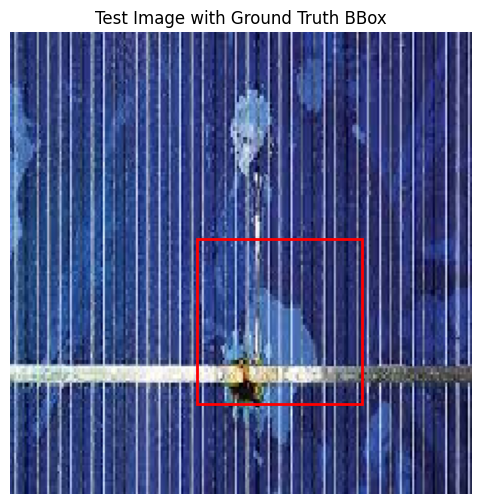

In [146]:
import cv2

# ==================================================
# HEATMAP QUALITY (Variance of the heatmap)
# ==================================================
heatmap_quality = np.var(heatmap_test)

# ==================================================
# POINTING ACCURACY (Requires a ground truth bounding box)
# NOTE: This part requires you to manually define a ground truth bounding box
# for the test image. For demonstration, I will use a placeholder.
# If you have actual ground truth annotations, please replace this.
# Example: [xmin, ymin, xmax, ymax]

# Placeholder for ground truth bounding box for image_1.jpg
# You need to adjust this based on the actual damage location in your image.
# For 'Electrical-damage', let's assume a rough area.
# You might need a tool to get precise coordinates.
# For now, I'll use a general area assuming it's in the center-ish region.

# Please replace this with actual coordinates if you have them:
if predicted_label_test == 'Electrical-damage':
    gt_bbox_test = [90, 100, 170, 180] # Example: [xmin, ymin, xmax, ymax] for image_1.jpg electrical damage
else:
    gt_bbox_test = [50, 50, 150, 150] # Generic placeholder if not electrical damage

# Find the point of maximum activation in the heatmap
max_pos = np.unravel_index(
    np.argmax(heatmap_test),
    heatmap_test.shape
)
y_point, x_point = max_pos

# Scale the point coordinates back to the original image size (224x224)
img_h, img_w, _ = tf.convert_to_tensor(img_test).shape
heatmap_h, heatmap_w = heatmap_test.shape

x_point_scaled = int(x_point * img_w / heatmap_w)
y_point_scaled = int(y_point * img_h / heatmap_h)

# Check if the point of maximum activation falls within the ground truth bbox
inside_bbox = (
    gt_bbox_test[0] <= x_point_scaled <= gt_bbox_test[2] and
    gt_bbox_test[1] <= y_point_scaled <= gt_bbox_test[3]
)
pointing_accuracy = int(inside_bbox) * 100 # Convert to percentage

# ==================================================
# IoU CALCULATION (Requires ground truth bounding box and binary heatmap)
# ==================================================

# Resize heatmap to match original image dimensions
heatmap_resized_for_iou = cv2.resize(
    heatmap_test,
    (img_w, img_h)
)

# Create a binary heatmap (threshold at 0.5 to identify 'activated' regions)
binary_heatmap_for_iou = np.uint8(heatmap_resized_for_iou > 0.5)

# Create ground truth mask from the bounding box
gt_mask_for_iou = np.zeros(
    (img_h, img_w),
    dtype=np.uint8
)
gt_mask_for_iou[
    gt_bbox_test[1]:gt_bbox_test[3],
    gt_bbox_test[0]:gt_bbox_test[2]
] = 1

# Calculate Intersection
intersection = np.logical_and(
    binary_heatmap_for_iou,
    gt_mask_for_iou
).sum()

# Calculate Union
union = np.logical_or(
    binary_heatmap_for_iou,
    gt_mask_for_iou
).sum()

# Calculate IoU
iou_score = intersection / union if union > 0 else 0

# ==================================================
# DISPLAY RESULTS
# ==================================================
print("\n--- Explainability Metrics ---")
print(f"Predicted Class    : {predicted_label_test}")
print(f"Heatmap Quality    : {heatmap_quality:.4f}")
print(f"Pointing Accuracy  : {pointing_accuracy:.2f}%")
print(f"IoU Score          : {iou_score:.4f}")

# Optionally, visualize the GT bbox on the original image to verify
fig_bbox = plt.figure(figsize=(6, 6))
plt.imshow(tf.convert_to_tensor(img_test).numpy().astype("uint8"))
plt.title("Test Image with Ground Truth BBox")
plt.axis("off")

# Draw bounding box (red rectangle)
rect = plt.Rectangle((gt_bbox_test[0], gt_bbox_test[1]),
                     gt_bbox_test[2] - gt_bbox_test[0],
                     gt_bbox_test[3] - gt_bbox_test[1],
                     fill=False, edgecolor='red', linewidth=2)
plt.gca().add_patch(rect)
plt.show()
